In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize

In [2]:
im_path = "/data/datasets/nii/MSD/Task10_Colon/imagesTs/colon_001.nii.gz"
gt_path = "/data/datasets/nii/MSD/Task10_Colon/labelsTs/colon_001.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [3]:
im.shape, gt.shape

((512, 512, 60), (512, 512, 60))

In [4]:
scale = 255
im = torch.Tensor(im)
im = (im - im.min()) / (im.max() - im.min()) * scale
# im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)
# im = normalize(
#     im, 
#     mean=[0.485 * scale, 0.456 * scale, 0.406 * scale],
#     std=[0.229 * scale, 0.224 * scale, 0.225 * scale]
# )
# im = im * 255
# im = im.permute(0, 2, 3, 1)

In [5]:
im.min(), im.max()

(tensor(0.), tensor(255.))

In [6]:
np.unique(gt)

array([0., 1.])

In [7]:
gt[gt != 1] = 0
gt[gt == 1] = 1

In [8]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

array([51, 52, 53])

In [9]:
im.shape, gt.shape

(torch.Size([512, 512, 60]), (512, 512, 60))

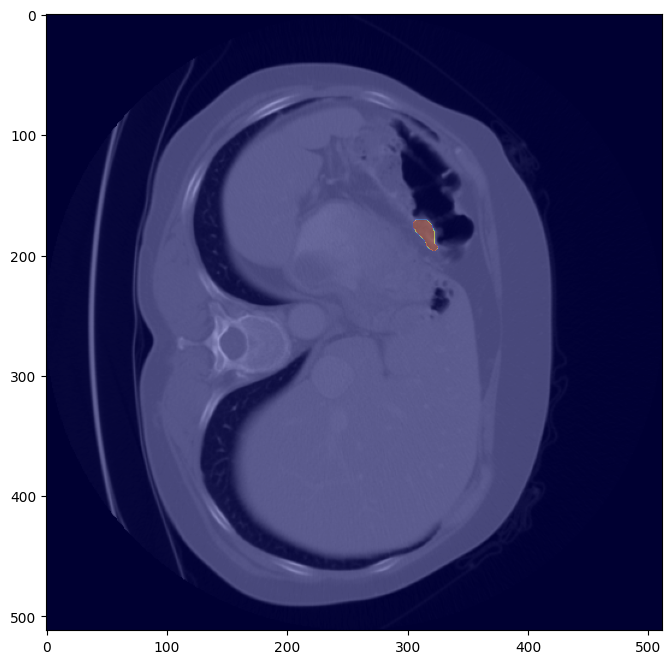

In [15]:
plt.figure(figsize=(8,8))
plt.imshow(im[:, :, 53], cmap="grey")
plt.imshow(gt[:, :, 53], alpha=0.4, cmap="jet")